In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sn

plt.style.use("ggplot")

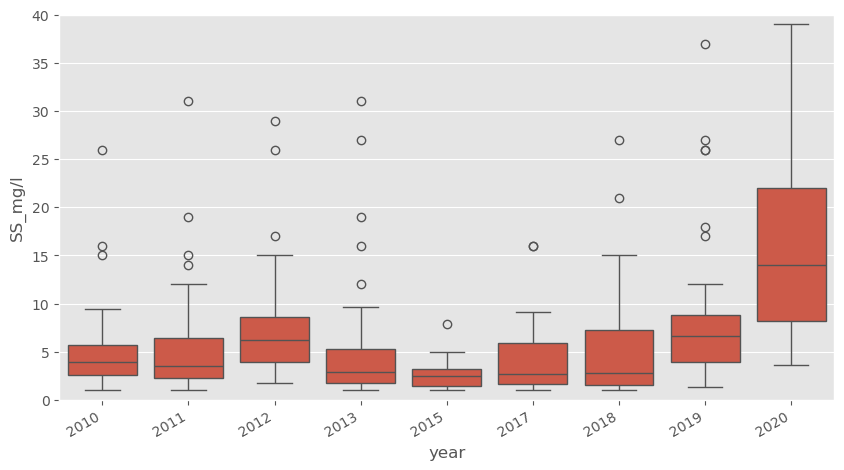

In [3]:
stn_id = "002-30586"
par = "TOTP_µg/l"
par = "SS_mg/l"
st_yr = 2010
end_yr = None

xl_path = r"../data/cleaned_concs_stations.xlsx"
wc_df = pd.read_excel(xl_path, sheet_name="cleaned_chem").query(
    "station_code == @stn_id"
)
if st_yr:
    wc_df = wc_df.query("year >= @st_yr")
if end_yr:
    wc_df = wc_df.query("year <= @end_yr")

plt.figure(figsize=(10, 5))  # width, height in inches
sn.boxplot(data=wc_df, x="year", y=par)
plt.ylim((0, 40))
# plt.ylim((0, 100))
plt.xticks(rotation=30, ha="right");

In [21]:
stn_ids = ["002-30586", "002-79092"]

xl_path = r"../data/vannmiljo_data_waterbodies.xlsx"
wc_df = pd.read_excel(xl_path, sheet_name="data_wide").query(
    "(station_code in @stn_ids) and (sample_date >= '2013-01-01')"
)[["station_code", "sample_date", "TOTP_µg/l"]]

wc_df = wc_df.pivot_table(
    index="sample_date", columns="station_code", values="TOTP_µg/l", aggfunc="mean"
)

xl_path = r"../data/nve_data.xlsx"
q_df = (
    pd.read_excel(xl_path, sheet_name="gts-api")
    .query("date >= '2013-01-01'")
    .set_index("date")[stn_ids]
)
q_df.columns = [f"q_{col}" for col in q_df]

df = pd.concat([wc_df, q_df], axis="columns")
df.head()

,002-30586,002-79092,q_002-30586,q_002-79092
2013-01-01,NaN,NaN,8.137879,8.127263
2013-01-02,NaN,NaN,9.600806,9.588281
2013-01-03,NaN,NaN,8.747895,8.736483
2013-01-04,NaN,NaN,7.939484,7.929127
2013-01-05,NaN,NaN,7.323906,7.314351


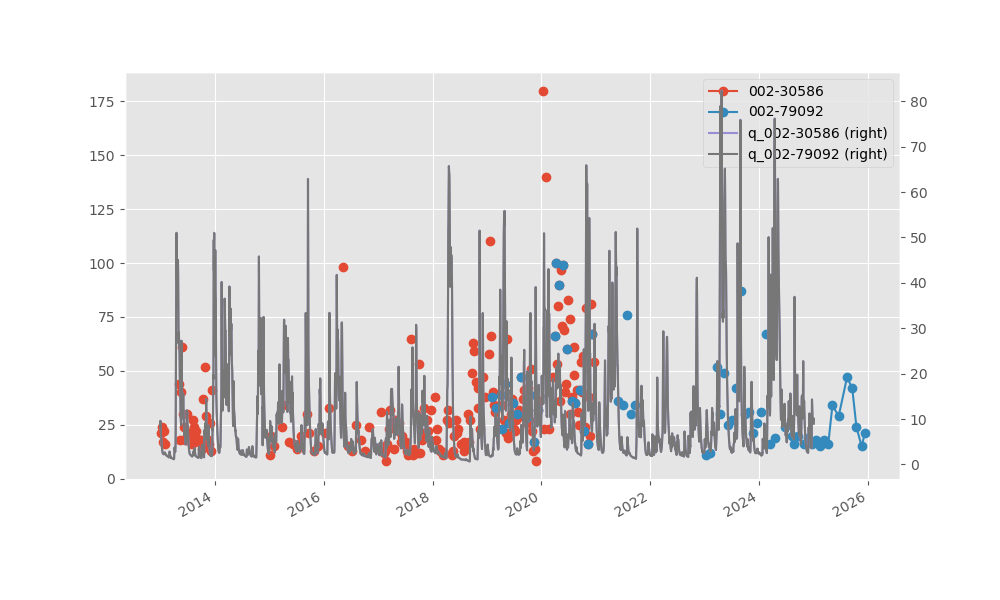

In [25]:
%matplotlib ipympl


q_cols = [c for c in df.columns if c.startswith('q_')]
main_cols = [c for c in df.columns if not c.startswith('q_')]
style = {col: '-' for col in q_cols}
style.update({col: 'o-' for col in main_cols})

ax = df.plot(figsize=(10, 6), secondary_y=q_cols, style=style)